# **Misaligned Jets of the Lighthouse nebula (PSR J1101–6101)**

Maksim Kleimenov

24, 26, 31 March 2026

In [1]:
import numpy as np
import pandas as pd

import astropy.units as u
import matplotlib.pyplot as plt

from src.xray_data import butterfly_data
from config.settings import DATA_DIR

from config.plotting import set_plotting_defaults

## Chapter 1. **Summarize experimental data**

### Part 1. **Chandra, NuSTAR, Fermi-LAT [Klingler et al., 2023]**

Download the experimental data

#### 1.1 **X-ray emission**

In their analysis, Klinger et al. assume an absorbed power-law model. X-ray absorption takes place in the neutral gas due to photoelectric effect. The strongest contribution comes from heavier elements, e.g. C, O, Fe. However, in the *hydrogen column density* we take into account **all** neutral gas in the line of sight

(how??) [REF???]

In [2]:
# Data from [Klingler et al., 2023]

LIGHTHOUSE_DIR = DATA_DIR / "lighthouse"

chandra_2023 = pd.read_csv(LIGHTHOUSE_DIR / "chandra_2023.csv")
nustar_2023 = pd.read_csv(LIGHTHOUSE_DIR / "nustar_2023.csv")
fermi_2023 = pd.read_csv(LIGHTHOUSE_DIR / "fermi_2023.csv")

flux_unit = 1 / (u.s * u.cm**2 * u.keV)
energy_flux_unit = u.erg / (u.cm**2 * u.s)

In [3]:
def get_2023_xray(energy_range, table, if_areawise=True, ref_energy=1 * u.keV, if_compensation=False):
    areas = []
    models = []
    low = []
    upper = []
    for i, s in enumerate(table["Segment"]):

        area = 1 * (u.cm**2 / u.cm**2)
        if if_areawise:
            area = (table["Area"][i] * u.arcsec**2).to(u.arcmin**2)
            
        compensation_coefficient = 1
        if if_compensation:
            compensation_coefficient = table["Const"][i]

        normalization = table["Norm"][i] * 1e-5 * compensation_coefficient * flux_unit
        normalization_error = table["NormErr"][i] * 1e-5 * compensation_coefficient * flux_unit

        pwl_index = -table["Gamma"][i]
        pwl_index_error = -table["GammaErr"][i]
        
        output_unit = energy_flux_unit / area.unit

        model, model_lower, model_upper = butterfly_data(energy_range,
                                                         normalization / area, normalization_error / area,
                                                         pwl_index, pwl_index_error,
                                                         ref_energy)
        model = (model * energy_range**2).to(output_unit)
        model_lower = (model_lower * energy_range**2).to(output_unit)
        model_upper = (model_upper * energy_range**2).to(output_unit)

        areas.append(area)
        models.append(model)
        low.append(model_lower)
        upper.append(model_upper)
    return models, low, upper, areas

In [4]:
chandra_2023_range = np.logspace(np.log10(0.5), np.log10(8), 100) * u.keV
chandra_2023_models, chandra_2023_low, chandra_2023_upper, chandra_2023_areas = get_2023_xray(chandra_2023_range, chandra_2023,
                                                                                              if_areawise=False, if_compensation=False)
chandra_2023_total = np.sum(chandra_2023_models, axis=0)
chandra_2023_total_low = np.sum(chandra_2023_low, axis=0)
chandra_2023_total_upper = np.sum(chandra_2023_upper, axis=0)

In [5]:
nustar_2023_range = np.logspace(np.log10(3), np.log10(79), 100) * u.keV
nustar_2023_models, nustar_2023_low, nustar_2023_upper, nustar_2023_areas = get_2023_xray(nustar_2023_range, nustar_2023,
                                                                                          if_areawise=False, if_compensation=True)
nustar_2023_total = np.sum(nustar_2023_models, axis=0)
nustar_2023_total_low = np.sum(nustar_2023_low, axis=0)
nustar_2023_total_upper = np.sum(nustar_2023_upper, axis=0)

#### 1.1a Gamma-ray measurements from catalog

In [6]:
data = pd.read_csv(f"{LIGHTHOUSE_DIR}/Filament.csv")
data.head()

,energy,Flux,Type,Label
0,0.812425,3.590196e-15,0,Data
1,0.812425,9.174838e-15,0,Upper
2,0.810704,1.032237e-16,0,Lower
3,0.886190,1.000000e-15,1,Data
4,0.886190,4.975657e-15,1,Upper


In [7]:
data_data = (data[data["Label"] == "Data"][["energy", "Flux"]]).reset_index(drop=True)
data_upper = (data[data["Label"] == "Upper"][["Flux"]]).reset_index(drop=True)
data_lower = (data[data["Label"] == "Lower"][["Flux"]]).reset_index(drop=True)

In [8]:
data_data["Upper"] = data_upper["Flux"] 
data_data["Lower"] = data_lower["Flux"]

flux = data_data
flux.head()

,energy,Flux,Upper,Lower
0,0.812425,3.590196e-15,9.174838e-15,1.032237e-16
1,0.886190,1.000000e-15,4.975657e-15,1.032237e-16
2,0.966653,1.624164e-14,2.046556e-14,1.237427e-14
3,1.054422,2.543969e-14,2.954421e-14,2.190540e-14
4,1.152601,3.722769e-14,4.207419e-14,3.249459e-14


In [9]:
flux["Flux"] = flux["Flux"] * flux["energy"]
flux["Upper"] = flux["Upper"] * flux["energy"]
flux["Lower"] = flux["Lower"] * flux["energy"]

In [12]:
from synchrotron.attenuation_photoelectric import photoelectric_optical_depth

hi_cd = 0.99e22 * u.cm**(-2)

pod = photoelectric_optical_depth(np.array(flux.energy) * u.keV, hI_column_density=hi_cd)

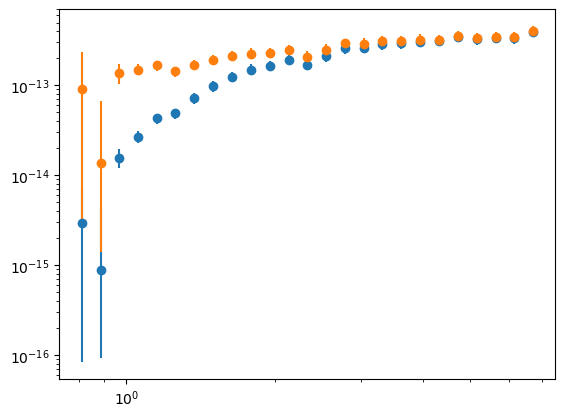

In [16]:
plt.errorbar(flux.energy, flux.Flux, yerr=[flux.Flux - flux.Lower, flux.Upper - flux.Flux], fmt='o')
plt.errorbar(flux.energy, flux.Flux * pod,
             yerr=[(flux.Flux - flux.Lower) * pod, (flux.Upper - flux.Flux) * pod],
             fmt='o')
plt.xscale('log')
plt.yscale('log')

#### 1.2. **Gamma-ray upper limits from Fermi-LAT**

In the analysis, Klinger et al. investigate Fermi-LAT data in the bins from 0.3 to 3 GeV and from 3 to 30 GeV. They were not able to detect any sources (extended or point-like), hence they place upper constraints.

In [17]:
energy_unit = u.keV
fermi_min_energies = (np.array(fermi_2023["emin"]) * u.GeV).to(energy_unit)
fermi_max_energies = (np.array(fermi_2023["emax"]) * u.GeV).to(energy_unit)
fermi_energies = np.sqrt(fermi_min_energies * fermi_max_energies).to(energy_unit)
fermi_errors = [fermi_energies - fermi_min_energies,
                fermi_max_energies - fermi_energies]
fermi_fluxes = fermi_2023["ulim"] * energy_flux_unit

#### 1.3. **Joint spectrum**

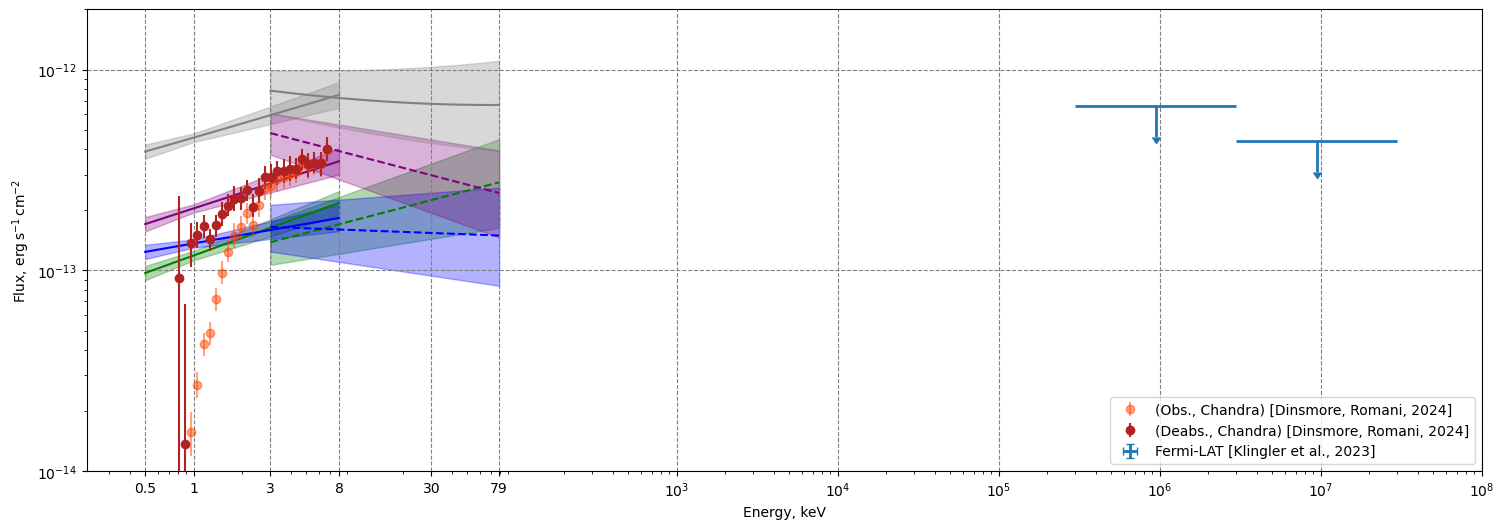

In [23]:
plt.figure(figsize=(18, 6))
ax = plt.subplot(111)

colors = ['green', 'blue', 'purple']

# chandra data
for i in range(len(chandra_2023_models)):
    ax.loglog(chandra_2023_range, chandra_2023_models[i], color=colors[i])
    ax.fill_between(chandra_2023_range.value, chandra_2023_low[i].value, chandra_2023_upper[i].value, alpha=0.3, color=colors[i])
# total chandra
ax.loglog(chandra_2023_range, chandra_2023_total, color='gray')
ax.fill_between(chandra_2023_range.value, chandra_2023_total_low, chandra_2023_total_upper, alpha=0.3, color='grey')

# nustar data
for i in range(len(nustar_2023_models)):
    ax.loglog(nustar_2023_range, nustar_2023_models[i], color=colors[i], linestyle='dashed')
    ax.fill_between(nustar_2023_range.value, nustar_2023_low[i].value, nustar_2023_upper[i].value, alpha=0.3, color=colors[i])
# total nustar
ax.loglog(nustar_2023_range, nustar_2023_total, color='gray')
ax.fill_between(nustar_2023_range.value, nustar_2023_total_low, nustar_2023_total_upper, alpha=0.3, color='grey')

# chandra data
plt.errorbar(flux.energy, flux.Flux, yerr=[flux.Flux - flux.Lower, flux.Upper - flux.Flux],
             fmt='o', color='orangered', alpha=.5,
             label="(Obs., Chandra) [Dinsmore, Romani, 2024]")
# chandra deabsorbed data
plt.errorbar(flux.energy, flux.Flux * pod, yerr=[(flux.Flux - flux.Lower) * pod, (flux.Upper - flux.Flux) * pod],
             fmt='o', color='firebrick',
             label="(Deabs., Chandra) [Dinsmore, Romani, 2024]")

# fermi upper limits
plt.errorbar(fermi_energies, fermi_fluxes, xerr=fermi_errors, yerr=0.3 * fermi_fluxes, uplims=True,
             linewidth=0, elinewidth=2, label="Fermi-LAT [Klingler et al., 2023]")

ax.grid(True, linestyle='--', color='grey')

ax.set_xlabel("Energy, keV")
ax.set_xticks([0.5, 1, 3, 8, 30, 79, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8],
              ['0.5', '1', '3', '8', '30', '79', r'$10^3$', r'$10^4$', r'$10^5$', r'$10^6$', r'$10^7$', r'$10^8$'])

ax.set_ylabel(r"Flux, $\mathrm{erg\,s^{-1}\,cm^{-2}}$")
# ax.set_ylabel(r"Flux, $\mathrm{erg\,s^{-1}\,cm^{-2}\,arcmin^{-2}}$")
# ax.set_ylim(8e-14, 2e-12)
ax.set_ylim(1e-14, 2e-12)

ax.legend(loc=4)

plt.show()

#### 1.4. **Maps** from Klingler et al.

In [8]:
from astropy.io import fits
from astropy.wcs import WCS

In [9]:
MAPS_DIR = LIGHTHOUSE_DIR / "maps"
map_names = ["chandra_2016", "chandra_2023", "nustar_3-20", "nustar_20-25", "nustar_25-50", "nustar_50-70"]
map_files = ["lighthouse_chandra.fits",
             "lighthouse_chandra-2023.fits",
             "lighthouse_nustar_3-20keV.fits",
             "lighthouse_nustar_20-25keV.fits",
             "lighthouse_nustar_25-50keV.fits",
             "lighthouse_nustar_50-70keV.fits"]
energies = [[1,6], [3,20], [20,25], [25,50], [50,79]] * u.keV

In [10]:
def reshape_the_image(fits_data):
    fits_shape = fits_data.shape
    img_data = np.zeros([fits_shape[1], fits_shape[2], fits_shape[0]])
    for i in range(fits_shape[0]):
        for j in range(fits_shape[1]):
            for k in range(fits_shape[2]):
                img_data[j,k,i] = fits_data[i,j,k]
    return np.int_(img_data)

In [11]:
wcss = []
maps = []
for i in range(len(map_files)):
    data_map = fits.open(MAPS_DIR / map_files[i], mode='readonly')
    wcss.append(WCS(data_map[0].header))
    maps.append(reshape_the_image(data_map[0].data))

the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]


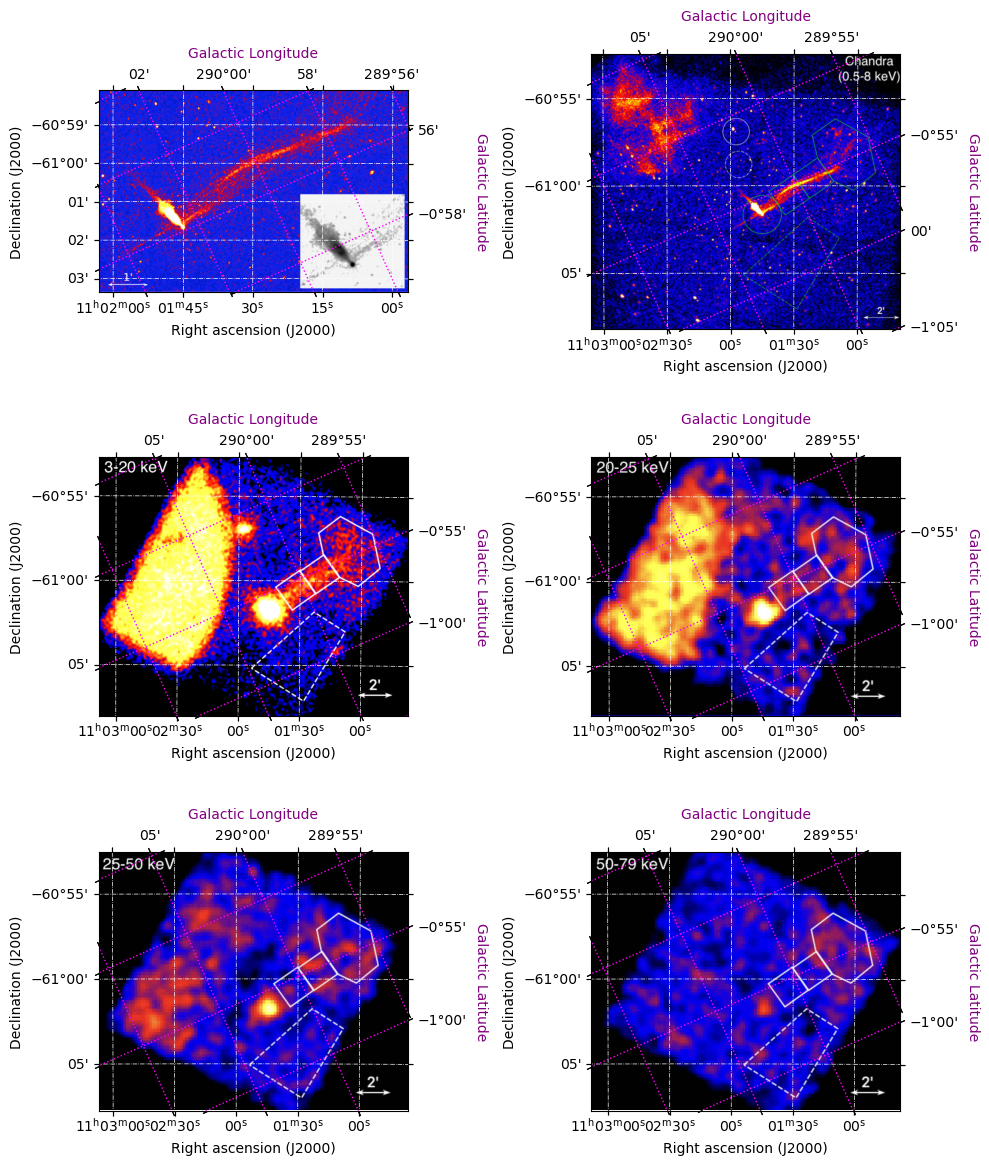

In [12]:
fig = plt.figure(figsize=(10, 12))
plot_number = 1
for i in range(len(maps)):
    ax = fig.add_subplot(3, 2, plot_number+i, projection=wcss[i][0])
    plt.imshow(maps[i], origin='lower')
    ax.coords.grid(True, color='white', ls='dashdot', linewidth=.5)
    ax.set(xlabel='Right ascension (J2000)', ylabel='Declination (J2000)')

    overlay = ax.get_coords_overlay('galactic')
    overlay.grid(color='magenta', ls='dotted', linewidth=1)
    overlay[0].set_axislabel('Galactic Longitude', color='purple')
    overlay[1].set_axislabel('Galactic Latitude', color='purple')

plt.tight_layout()
plt.show()

#### 1.5. Another way to represent the spectra

In [13]:
boundaries = [60, 160, 260, 440]  # in seconds

# TODO: finish the three-plot-in-one-axis

### Part 2. **Chandra detailed study [Pavan et al., 2016]**

In this work, the authors conduct a detailed study of Chandra measurements.

#### Voronoi cells, power-law index and flux as a function of distance

By comparing two plots (Fig. 8, upper and lower panels), we were able to find correspondance between each flux, index and distance.

These two figures correspond to

In [14]:
data_2016 = pd.read_csv("data/lighthouse/data_points_2016.csv")
d = data_2016

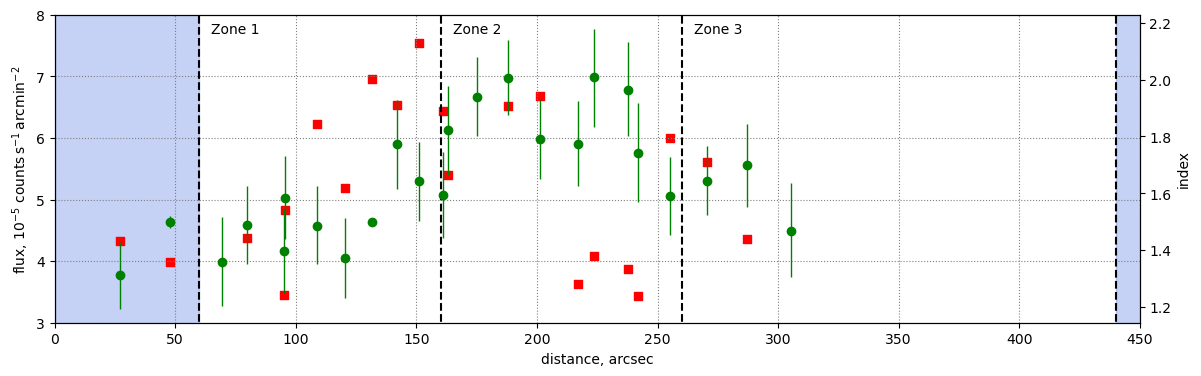

In [15]:
plt.figure(figsize=(14, 4))
ax = plt.subplot(111)

# show boundaries of the Klingler's squares
ax.fill_betweenx([0, 10], [0, 0], [boundaries[0], boundaries[0]], color='royalblue', alpha=.3)
ax.fill_betweenx([0, 10], [boundaries[-1], boundaries[-1]], [500, 500], color='royalblue', alpha=.3)
for i in range(1, 4): ax.text(boundaries[i-1]+5, 7.7, f'Zone {i}')
ax.vlines(boundaries, 0, 10, linestyle='dashed', color='black')

# flux points
ax.scatter(d.x, d.flux, color='red', marker='s')
ax.set_xlabel("distance, arcsec")
ax.set_ylabel(r"flux, $\mathrm{10^{-5}~counts\,s^{-1}\,arcmin^{-2}}$")
ax.grid(linestyle='dotted', color='gray')
ax.set_xlim(0, 450)
ax.set_ylim(3, 8)

ax2 = ax.twinx()
ax2.errorbar(d.x, d.y, yerr=[d.y - d.ymin, d.ymax - d.y], linewidth=0, elinewidth=1, color='green', marker='o')
ax2.set_ylabel("index")

plt.show()

To check if the values are correlated, we also show index-flux plot

In [16]:
from scipy.stats import pearsonr

In [17]:
pr = pearsonr(d.flux, d.y)
print(pr)

PearsonRResult(statistic=np.float64(0.2897570681715241), pvalue=np.float64(0.16962466252638553))


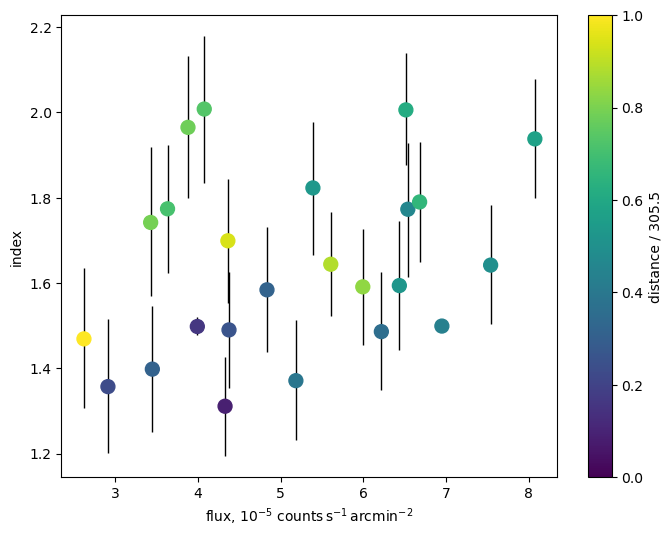

In [18]:
plt.figure(figsize=(8, 6))
cmap = plt.get_cmap('viridis')
color = cmap(d.x/np.max(d.x))
plt.errorbar(d.flux, d.y, yerr=[d.y - d.ymin, d.ymax - d.y],
             linewidth=0, elinewidth=1, color='black')
s = plt.scatter(d.flux, d.y, color=color, s=100, zorder=2)
plt.xlabel(r"flux, $\mathrm{10^{-5}~counts\,s^{-1}\,arcmin^{-2}}$")
plt.ylabel("index")
cb = plt.colorbar(s)
cb.set_label(f"distance / {np.max(d.x):.1f}")
plt.show()

Well, a slight increasing trend is observed (Pearson $R\approx 0.3$ ), however it is insignificant (p-value > 0.16)

#### Normalized counts profile along the 'main jet'

In [19]:
data_nc_2016 = pd.read_csv("data/lighthouse/norm_counts-dist_2016.csv")

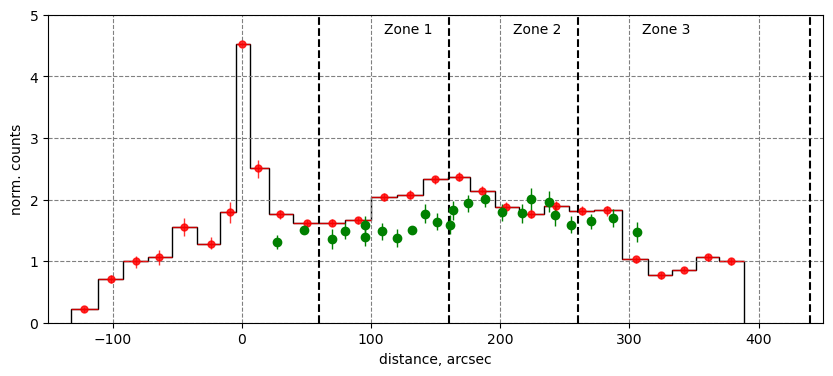

In [20]:
plt.figure(figsize=(10, 4))

edges = np.unique(np.concatenate([data_nc_2016.xmin.to_numpy(), data_nc_2016.xmax.to_numpy()]))

plt.stairs(data_nc_2016.y, edges, color='black')
plt.errorbar(data_nc_2016.x, data_nc_2016.y,
             xerr = [data_nc_2016.x - data_nc_2016.xmin, data_nc_2016.xmax - data_nc_2016.x],
             yerr = [data_nc_2016.y - data_nc_2016.ymin, data_nc_2016.ymax - data_nc_2016.y],
             elinewidth=1, linestyle='None', marker='o', markersize=5, alpha=.8,
             color='red')
plt.errorbar(d.x, d.y, yerr=[d.y - d.ymin, d.ymax - d.y], linewidth=0, elinewidth=1, color='green', marker='o')

for i in range(1, 4): plt.text(boundaries[i-1]+50, 4.7, f'Zone {i}')
plt.vlines(boundaries, 0, 10, linestyle='dashed', color='black')

plt.grid(True, linestyle='--', color='gray')

plt.xlabel('distance, arcsec')
plt.ylabel('norm. counts')

plt.xlim(-150, 450)
plt.ylim(0, 5)

plt.show()

## Chapter 2. **Semi-analytical theoretical models**

In [21]:
from synchrotron.synchrotron_emission import electron_synchrotron_emission_luminosity
from inverse_compton.klein_nishina import klein_nishina_on_CMB

### Part 1. **Simplest possible model:** electron streaming + synchrotron cooling

#### 1. **Synchrotron cooling timescale**

Total energy loss rate for a single electron (eq. 4.5 from [Blumenthal, Gould, 1970] or [BG70] in further):

$ -\dot{E} = \dfrac{2r_0^2}{3c}\gamma^2 B^2 c^2 \sin^2\alpha = \dfrac{2e^4B^2c\sin^2\alpha}{3(mc^2)^4}E^2 = AE^2 $

One introduces *synchrotron losses timescale*:
    
$ \tau_\mathrm{syn} = \left|\dfrac{E}{\dot{E}}\right| = \dfrac{1}{AE} = \dfrac{3(mc^2)^4}{2e^4c}\dfrac{1}{B^2}\dfrac{1}{\sin^2\alpha}\dfrac{1}{E}$

In [22]:
import astropy.units as u
import astropy.constants.codata2010 as cst

from config.units import uGauss
from config.constants import CST_m_e, CST_e

In [23]:
def get_synch_A(b, alpha=90*u.deg):
    return 2 * CST_e**4 * b**2 * cst.c * np.sin(alpha)**2 / (3 * CST_m_e**4)

In [24]:
def total_synch_power(e, b, alpha=90*u.deg):
    return (2*CST_e**4 * b**2 * cst.c * np.sin(alpha)**2 / (3 * CST_m_e**4) * e**2).to(u.eV / u.s)

In [25]:
def synchrotron_cooling_time(e, b, alpha=90*u.deg):
    t_syn = 3 * CST_m_e**4 / (2 * CST_e**4 * cst.c) * b**(-2) * np.sin(alpha)**(-2) * e**(-1)
    return t_syn.to(u.kyr)

print(f"{synchrotron_cooling_time(1*u.TeV, 1*uGauss, 90*u.deg):.1f}")

8353.2 kyr


Hence, synchrotron cooling timescales can be written as

$\tau_\mathrm{syn} = 8.35~\mathrm{Myr}~\left(\dfrac{B}{\mathrm{\mu G}}\right)^{-2} \left(\dfrac{\sin^2\alpha}{\sin^2 90^\circ}\right)^{-2} \left(\dfrac{E}{\mathrm{TeV}}\right)^{-1}$

#### 2. **Synchrotron cooling of electron spectrum**

If we assume that there's nothing more but synchrotron cooling of the electron spectrum, we obtain the following results.

1. Start from a powerlaw spectrum:

    $ N(E) = N_0\left(\dfrac{E}{E_0}\right)^{-s} $

2. Electron energy evolution with synchrotron losses:

    $ E_c(E, t) = \dfrac{E}{1 + AEt}, $ where $E_c$ is the resulting energy after cooling from $E$ during time $t$.

    $ E_i(E, t) = \dfrac{E}{1 - AEt}, $ where $E_i$ is the initial energy, from which electron cooled down to $E$ during time $t$.

3. Spectrum modification *(from solution of conservation equation in phase space)*

    $ N(E, t) = N_i\left(E_i(E, t)\right)\times(1 - AEt)^{-2} = N\left(\dfrac{E}{1 - AEt}\right)\times\dfrac{1}{(1 - AE_ct)^{2}} $

    For our power-law spectrum means the following:

    $ N(E, t) = N_0 \left(\dfrac{E}{E_0}\right)^{-s}\big(1 - AEt\big)^{s-2} $,

    which is correct only for $E < E_M = 1/At$.

In [26]:
def electron_max_energy_syn(b, t, alpha=90*u.deg):
    return (1 / (get_synch_A(b, alpha) * t)).to(u.TeV)

print(f"{electron_max_energy_syn(1*uGauss, 1*u.kyr, alpha=90*u.deg):.1f}")

8353.2 TeV


In [27]:
print((CST_e * uGauss * u.klyr).to(u.PeV))

283.62556428504996 PeV


Thus, we write

$ E_M = 8.35~\mathrm{PeV} \left(\dfrac{t}{\mathrm{kyr}}\right)^{-1} \left(\dfrac{B}{\mathrm{\mu G}}\right)^{-2} \left(\dfrac{\sin\alpha}{\sin 90^\circ}\right)^{-2} \quad (2\circ)$

In [27]:
Electron_energy = np.logspace(9, 17, 200) * u.eV  # from GeV to PeV
Ref_energy = 1 * u.TeV  # reference energy
S = 2.2  # electron index
B = 10 * uGauss
Pitch_angle = 90 * u.deg
N0 = 1e44 / u.eV

In [28]:
def cooled_pwl_spectrum(e, norm, index, t, ref=1*u.TeV, b=1*uGauss, alpha=90*u.deg):
    e_max = electron_max_energy_syn(b, t, alpha)
    a = get_synch_A(b, alpha)
    cs = np.zeros_like(e.value) * norm.unit
    # choose available energies
    good_i = (e <= e_max)
    good_e = e[good_i]
    cs[good_i] = norm * (good_e/ref)**(-index) * (1 - a*good_e*t)**(index - 2)
    return cs

/home/maxkl/miniforge3/envs/gammapy-2.0/lib/python3.12/site-packages/astropy/units/quantity.py:653: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


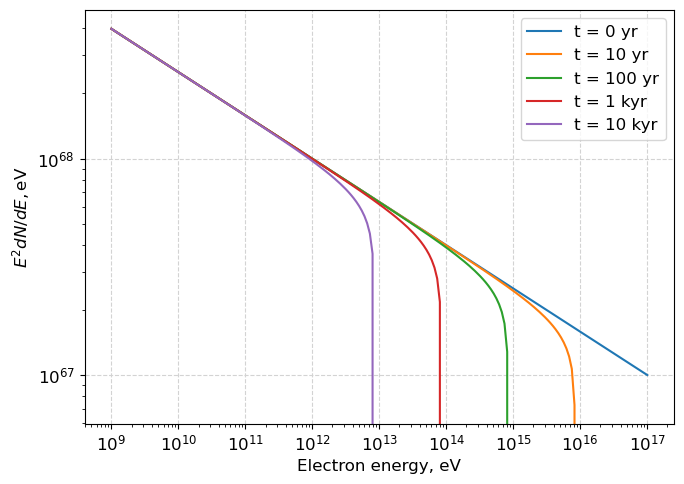

In [29]:
set_plotting_defaults()
plt.figure()
for time in [0*u.yr, 10*u.yr, 100*u.yr, 1*u.kyr, 10*u.kyr]:
    plt.loglog(Electron_energy, Electron_energy**2 * cooled_pwl_spectrum(Electron_energy, N0, S, time, ref=Ref_energy, b=B, alpha=Pitch_angle),
               label=f"t = {time:.3g}")
plt.xlabel('Electron energy, eV')
plt.ylabel(r'$E^2 dN/dE, \mathrm{eV}$')
plt.legend()
plt.tight_layout()
plt.show()

#### 3. **Basic synchrotron emission properties**

Here we use the simplest possible approximation for the synchrotron emission function.

As we have already mentioned,

$ -\dot{E}_\mathrm{syn} = -AE^2 $

This energy loss comes from emitted power in synchrotron as stated by eq. (4.44) from [BG70]:

$ P_\mathrm{emitted}(\epsilon) = \dfrac{\sqrt{3}e^3 B c}{mc^2\,hc} F_\mathrm{syn}\left(\dfrac{\epsilon}{\epsilon_c}\right) \times \sin\alpha , $

where $\epsilon_c = h\nu_c = \dfrac{3eBhc\gamma^2}{4\pi mc^2}\sin\alpha = \dfrac{3eB\hbar c \sin\alpha}{2(mc^2)^3} E^2,$ see eq. (4.45) in [BG70].

At the same time, the *first synchrotron function* $F_\mathrm{syn}$ behaves such that
$\epsilon_\mathrm{syn,peak} \approx 0.29 \epsilon_\mathrm{syn}$ (see [Ландау, Лифшиц, Том 2. Теория поля. с. 277 (пар. 74)] in firther [LL2])

In [30]:
def characteristic_synch_energy(e, b, alpha=90*u.deg):
    return (3 * CST_e * b * cst.hbar * cst.c * np.sin(alpha) / (2 * CST_m_e**3) * e**2).to(u.eV)

def synch_peak(e, b, alpha=90*u.deg):
    return 0.29 * characteristic_synch_energy(e, b, alpha)

print(f"{synch_peak(1*u.TeV, 1*uGauss, alpha=90*u.deg):.4f}")

0.0193 eV


Hence, we write

$ \epsilon_\mathrm{syn,peak} \approx 0.02~\mathrm{eV}\left(\dfrac{B}{\mathrm{\mu G}}\right) \left(\dfrac{\sin\alpha}{\sin 90^\circ}\right) \left(\dfrac{E}{\mathrm{TeV}}\right)^2 \quad (3*)$ 

#### 4. **Delta-function approximation of synchrotron emission**

Spectral synchrotron radiation power of a population of electrons, received by terrestrial observer is given by eq. (4.55) in [BG70]:

$ \dfrac{d\mathcal{E}}{d\epsilon dt} = \int dE \int d\Omega_\alpha\,P_\mathrm{emitted}(\epsilon | E, \alpha)\,N(E,\alpha,z,t_z) $

As cooling process is very slow, we can assume the population be time-independent on the observational timescales.

This allows for the following approximation of synchrotron emission power spectrum:

$ P_\mathrm{emitted}(\epsilon|E, \alpha) = P_\mathrm{total}(E_\epsilon,\alpha) \times \delta(\epsilon - \epsilon_\mathrm{syn,peak}[E]) $

In other words, as a delta-function in $E$-space, we obtain

$ P_\mathrm{emitted}(\epsilon|E, \alpha) = P_\mathrm{total}(E_\epsilon,\alpha) \times \delta(E - E_\epsilon) \times \left|\dfrac{d\epsilon_\mathrm{syn,peak}}{dE}\right|^{-1} $.

The Jacobian is given by $\left|\dfrac{d\epsilon_\mathrm{syn,peak}}{dE}\right| = 2\dfrac{\epsilon_\mathrm{syn,peak}}{E}$

Which means that

$ \dfrac{d\mathcal{E}}{d\epsilon dt} = \int d\Omega_\alpha\,P_\mathrm{total}(E, \alpha)\,N(E_\epsilon,\alpha,z)\times 2\dfrac{E_\epsilon}{\epsilon} $

with $E_\epsilon = \sqrt{\dfrac{1}{0.29} \dfrac{2(mc^2)^3}{3eB\hbar c \sin\alpha}} \times \sqrt{\epsilon}$

In [31]:
def synch_electron_energy(phot_e, b, alpha=90*u.deg):
    return np.sqrt(1/0.29 * 2 * CST_m_e**3 / (3 * CST_e * b * cst.hbar * cst.c * np.sin(alpha)) * phot_e).to(u.eV)

print(f"{synch_electron_energy(1*u.eV, 1*uGauss, alpha=90*u.deg).to(u.TeV):.1f}")

7.2 TeV


We write

$ E_\epsilon = 7.2~\mathrm{TeV}\left(\dfrac{B}{\mathrm{\mu G}}\right)^{-1/2} \left(\dfrac{\sin\alpha}{\sin90^\circ}\right)^{-1/2} \left(\dfrac{\epsilon}{\mathrm{eV}}\right)^{1/2} \quad (4\Delta) $

#### 5. **Observed synchrotron radiation**

As observers, we are interested in power radiated per solid angle:

$ \dfrac{d\mathcal{E}}{d\epsilon\,dt\,d\Omega_\alpha} = 2\dfrac{E_\epsilon}{\epsilon}P_\mathrm{total}(E_\epsilon,\alpha)\,N(E_\epsilon, \alpha, z)$

From the Earth, we can see only one particular angle $\alpha$.

$ d\mathcal{E}_\mathrm{obs} = d\mathcal{E}_\mathrm{emitted}(\alpha) = \dfrac{d\mathcal{E}}{d\epsilon\,dt\,d\Omega_\alpha} d\epsilon_\mathrm{em}\,dt_\mathrm{em}\,d\Omega_\alpha $

We are interested in the flux seen on Earth:
$ F_\mathrm{obs} = \dfrac{d\mathcal{E}_\mathrm{obs}}{d\epsilon_\mathrm{obs}\,dt_\mathrm{obs}\,dA_\perp} = 
\dfrac{d\mathcal{E}}{d\epsilon\,dt\,d\Omega_\alpha} \dfrac{d\epsilon_\mathrm{em}}{d\epsilon_\mathrm{obs}}\dfrac{dt_\mathrm{em}}{dt_\mathrm{obs}}\dfrac{d\Omega_\alpha}{dA_\perp}. $

To simplify, we note that

* As $\epsilon_\mathrm{em}$ is calculated in the lab. frame, $\epsilon_\mathrm{em} = \epsilon_\mathrm{obs}.$

* However, between two photons emitted within $dt_\mathrm{em}$, observer sees only $dt_\mathrm{obs} = \sin^2\alpha dt_\mathrm{em}$.

* $dA_\perp = D^2d\Omega_\alpha$.

Then, 

$F_\mathrm{obs} = \dfrac{d\mathcal{E}}{d\epsilon\,dt\,d\Omega_\alpha} \dfrac{1}{D^2\sin^2\alpha} = \dfrac{1}{D^2\sin^2\alpha}\dfrac{E_\epsilon}{\epsilon}P_\mathrm{total}(E_\epsilon,\alpha)\,N(E_\epsilon, \alpha, z) $

Explicitly, we obtain

$ \epsilon_\mathrm{obs} F_\mathrm{obs} (\epsilon| B, \alpha) = \dfrac{1}{D^2} \dfrac{2e^4B^2c}{3(mc^2)^4} E_\epsilon^3 N(E_\epsilon, \alpha, z) \quad (5**) $

In [32]:
def delta_function_synch_emission(el_spectrum_func, phot_e, b, alpha=90*u.deg):
    el_e = synch_electron_energy(phot_e, b, alpha)
    return (total_synch_power(el_e, b, alpha) * el_spectrum_func(el_e) * el_e / phot_e).to(1/u.s)

In [33]:
def synch_flux(phot_e, syn_func, el_spectrum_func, b, alpha=90*u.deg, dist=1*u.kpc):
    return (1/(dist**2 * np.sin(alpha)**2) * phot_e * syn_func(el_spectrum_func, phot_e, b, alpha)).to(energy_flux_unit)

#### 6. **Analytical estimations**

**6.1. Synchrotron radiation peak constraints**

According to authors of both papers, emission is seen at least in the band $[0.8, 50]~\mathrm{keV}$.

For electrons to radiate at $50~\mathrm{keV}$, we need to satisfy the initial condition $\epsilon_\mathrm{syn,peak}(E_\mathrm{max}) = 50~\mathrm{keV}.$


In [34]:
print(f"{synch_electron_energy(50*u.keV, 1*uGauss, alpha=90*u.deg).to(u.PeV):.2f}")

1.61 PeV


Use $(4\Delta)$ and obtain

$ E_\mathrm{max} \sim 1.6\,\mathrm{PeV} \left(\dfrac{B}{\mathrm{\mu G}}\right)^{-1/2} \left(\sin\alpha\right)^{-1/2}$

**6.2. Synchrotron cooling constraints**

At the same time, we meet strong synchrotron cooling constraints:

At the distance of $~300\,\mathrm{arcsec},$ Chandra still observes X-ray radiation with energy of at least $1~\mathrm{keV}$.

This means that cooling time has to be constrained.

Here we have to use both $(4\Delta)$ and $(2\circ)$ as we are interested at $\epsilon_\mathrm{syn,peak}(E_M(t)) = 1~\mathrm{keV}$.

Together, these formulas give

$\tau_\mathrm{max} = 1.16\,\mathrm{Myr}\left(\dfrac{B}{\mathrm{\mu G}}\right)^{-3/2} \left(\sin\alpha\right)^{-3/2} \left(\dfrac{\epsilon}{\mathrm{eV}}\right)^{-1/2}.$

In [35]:
e_el_keV = synch_electron_energy(1*u.keV, 1*uGauss, alpha=90*u.deg)
print(f"El. energy in 1 uG for synch at 1 keV is {e_el_keV.to(u.TeV):.1f}")
ltime_keV = synchrotron_cooling_time(e_el_keV, 1*uGauss, alpha=90*u.deg)
print(f"Maximal propagation time for 1 keV synchrotron in 1 uG is {ltime_keV.to(u.kyr):.1f}")

El. energy in 1 uG for synch at 1 keV is 227.7 TeV
Maximal propagation time for 1 keV synchrotron in 1 uG is 36.7 kyr


This provides the following constraint on propagation timescale:

$ \tau_\mathrm{max} = 36.7~\mathrm{kyr} \left(\dfrac{B}{\mathrm{\mu G}}\right)^{-3/2} \left(\dfrac{\sin\alpha}{\sin90^\circ}\right)^{-3/2}$

**6.3. Propagation timescales constraints**

At the distance of 7 kpc,

In [36]:
Dist = 7 * u.kpc

arcsec_scale = (Dist * (1 * u.arcsec / u.rad)).to(u.pc) / u.arcsec
print(f"Arcsecond: {arcsec_scale:.2g}")

arcmin_scale = (Dist * (1 * u.arcmin / u.rad)).to(u.pc) / u.arcmin
print(f"Arcminute: {arcmin_scale:.3g}")


Arcsecond: 0.034 pc / arcsec
Arcminute: 2.04 pc / arcmin


1 arcsec $\leftrightarrow~0.034\,\mathrm{pc}$

1 arcmin $\leftrightarrow~2.04\,\mathrm{pc}$

In [37]:
all_nebula = 300 * u.arcsec * arcsec_scale
print(f"Scale of the nebula: {all_nebula.to(u.pc):.1f}")

Scale of the nebula: 10.2 pc


Hence, the whole nebula has the size

$l_\mathrm{filament} \approx \dfrac{10\,\mathrm{pc}}{\sin\alpha} \approx \dfrac{33\,\mathrm{lyr}}{\sin\alpha}$

Longitudinal component of electron velocity is equal to $v_\parallel = c\cos\alpha$, which means that the electrons reach the end of the filament in

$\tau_\mathrm{tr} = \dfrac{66\,\mathrm{yr}}{\sin2\alpha}$

**6.4. Constraints on total power from synchroron flux**

The observed flux values also constrain possible magnetic field and timescales.

As stated in $(5**)$, $ \epsilon F_\mathrm{obs} (\epsilon| B, \alpha) = \dfrac{1}{D^2} \dfrac{2e^4B^2c}{3(mc^2)^4} E_\epsilon^3 N(E_\epsilon, \alpha, z) $.

Synchrotron radiation is seen from $\epsilon_\mathrm{min} = 0.5~\mathrm{keV}$ to $\epsilon_\mathrm{max} = 50~\mathrm{keV}$.

We are interested in the total flux $\Phi$ emitted by that population:

$\Phi(B, \alpha) = \int d\epsilon F_\mathrm{obs} (\epsilon|B, \alpha) = \int d\ln\epsilon\,\epsilon F_\mathrm{obs} (\epsilon|B, \alpha)$

$\Phi(B, \alpha) = \dfrac{1}{D^2} \dfrac{2e^4B^2c}{3(mc^2)^4} \int d\ln\epsilon \,E_\epsilon^3 N(E_\epsilon, \alpha, z) $

Assume a powerlaw electron spectrum:

$ N(E, \alpha) = K(\alpha)\left(\dfrac{E}{E_0}\right)^{-s}. $

Then

$\Phi(B, \alpha) = \dfrac{1}{D^2} \dfrac{2e^4B^2c}{3(mc^2)^4} \dfrac{K(\alpha)}{E_0^{-s}} \int d\ln\epsilon\,E_\epsilon^{3-s} $

Change variables: $\ln\epsilon \to \ln E$.

Then $\int d\ln\epsilon ... = \int d\ln E \left|\dfrac{d\ln\epsilon}{d\ln E}\right| ... = 2\int d\ln E ... $ as $\epsilon_c \propto E^2$

This means that $\Phi(B, \alpha) = \dfrac{1}{D^2} \dfrac{4e^4B^2c}{3(mc^2)^4} \dfrac{K(\alpha)}{E_0^{-s}} \int d\ln E \,E^{3-s} = \dfrac{1}{D^2} \dfrac{4e^4B^2c}{3(mc^2)^4} \times \dfrac{K(\alpha)E_0^3}{3-s} \left(\dfrac{E_\mathrm{max}}{E_0}\right)^{3-s},$ which is approximately correct for $ s < 3 $

At the same time, total electron energy in the power-law spectrum is given by

$ \mathcal{E}_\mathrm{tot} = \displaystyle \int d\Omega_\alpha \int_{E_\mathrm{min}}^{E_\mathrm{max}} dE\,E\, N(E, \alpha) = \dfrac{2\pi K(\alpha)E_0^2}{s-2} \left(\dfrac{E_\mathrm{min}}{E_0}\right)^{2-s},$ which is approximately correct for $s > 2$.

We additionnaly assumed here that the **injected particle distribution is homogeneuous in pitch angle**: $K(\alpha) = \dfrac{K}{2\pi}$ (half-sphere)

Thus, $K(\alpha) = \dfrac{\mathcal{E}_\mathrm{tot}(s-2)}{2\pi E_0^2}\left(\dfrac{E_\mathrm{min}}{E_0}\right)^{s-2}$, which gives

$\Phi(B, \alpha) = \dfrac{1}{D^2} \dfrac{4e^4B^2c}{3(mc^2)^4} \times \dfrac{s-2}{3-s} \mathcal{E}_\mathrm{tot}E_\mathrm{max}  \left(\dfrac{E_\mathrm{min}}{E_\mathrm{max}}\right)^{s-2}.$ 

In terms of injected power, it gives

$ \Phi(B, \alpha) = \dfrac{1}{D^2} \dfrac{4e^4B^2c}{3(mc^2)^4} \times \dfrac{s-2}{3-s} P \times (E_\mathrm{max} \tau_\mathrm{prop}) \left(\dfrac{\epsilon_\mathrm{min}}{\epsilon_\mathrm{max}}\right)^{s/2-1}. $

To fix the normalization constant, we use the total power consraint: $ \mathcal{E}_\mathrm{tot} < P_\mathrm{PSR} \times \tau_\mathrm{prop} = P_\mathrm{PSR}\times\dfrac{66~\mathrm{yr}}{\sin2\alpha}$.

In [38]:
flux_power = (1/(7*u.kpc)**2 * 4 * CST_e**4 * uGauss**2 * cst.c / (3 * CST_m_e**4) * (2.4-2)/(3-2.4) * 1e36 * u.erg/u.s * 1.61 * u.PeV * 66 * u.yr * 100**0.2).to(energy_flux_unit)/2
print(flux_power)

4.565916526081083e-11 erg / (s cm2)


$ \Phi(B, \alpha) = 4.6\times10^{-11} \left( \dfrac{B}{\mathrm{\mu G}}\right)^{3/2} \dfrac{1}{(\sin\alpha)^{3/2}\cos\alpha} \times P_{36},$ where $P_{36} = \dfrac{P}{10^{36}\mathrm{\frac{erg}{cm^2\cdot s}}}$

Observed total flux between $5$ and $50~\mathrm{keV}$ is equal to

$\Phi_\mathrm{exp} \approx \ln10\times 7\times10^{-12}\mathrm{\dfrac{erg}{cm^2\cdot s}} \times 2 \approx 3.2\times 10^{-11} \mathrm{\dfrac{erg}{cm^2\cdot s}}$

In [39]:
flux_exp = np.log(10) * 7 * 1e-12 * 2 * energy_flux_unit
print(flux_exp)
print(flux_exp / flux_power)

3.223619130191664e-11 erg / (s cm2)
0.7060179729037862


This places constraint on the $B^{3/2} (\sin\alpha)^{-3/2}(\cos\alpha)^{-1} < 0.7 $

**6.4a. CR density**

As we already figured out, 

$\Phi(B, \alpha) = \dfrac{1}{D^2} \dfrac{4e^4B^2c}{3(mc^2)^4} \times \dfrac{s-2}{3-s} \mathcal{E}_\mathrm{tot}E_\mathrm{max}  \left(\dfrac{\epsilon_\mathrm{min}}{\epsilon_\mathrm{max}}\right)^{s/2-1}.$ 

$\Phi(B, \alpha) = 4.4\times10^{-56}\mathrm{\dfrac{erg}{cm^2\cdot s}} \left(\dfrac{B}{\mathrm{\mu G}}\right)^{3/2}(\sin\alpha)^{-1/2}\dfrac{\mathcal{E}_\mathrm{tot}}{\mathrm{erg}}$ 

In [48]:
s = 2.4
e_max_50keV = synch_electron_energy(50 * u.keV, uGauss, 90*u.deg)
e_max_5keV = synch_electron_energy(50 * u.keV, 50 * uGauss, 30*u.deg)
print(e_max_5keV.to(u.TeV))
flux_tot = (1/(7*u.kpc)**2 * 4 * CST_e**4 * uGauss**2 * cst.c / (3 * CST_m_e**4) * (s-2) / (3-s) * u.eV * e_max_50keV * (0.5/50)**(s/2 - 1)).to(energy_flux_unit)
print(flux_tot)

322.0303569231409 TeV
1.1134260960814791e-68 erg / (s cm2)


Again use

$\Phi_\mathrm{exp} \approx 3.2\times 10^{-11} \mathrm{\dfrac{erg}{cm^2\cdot s}}$

and get

$\mathcal{E}_\mathrm{tot} = 2.9 \times 10^{57}~\mathrm{eV} \left(\dfrac{B}{\mathrm{\mu G}}\right)^{-3/2}(\sin\alpha)^{1/2} $


In [49]:
E = (flux_exp / flux_tot) * u.eV
E

<Quantity 2.89522505e+57 eV>

The tube volume is given by ($l = 10~\mathrm{pc}/\sin\alpha$, $r \leftrightarrow 10~\mathrm{arcsec}$)

$V = \pi r^2 l $

In [50]:
V = (np.pi * (10 * u.arcsec * arcsec_scale)**2 * 10 * u.pc).to(u.cm**3)
V

<Quantity 1.06303441e+56 cm3>

In [51]:
n = E / V
n

<Quantity 27.23547829 eV / cm3>

$ n = 27~\mathrm{cm}^{-3} \left(\dfrac{B}{\mathrm{\mu G}}\right)^{-3/2} (\sin\alpha)^{3/2} $

**6.5. Best-fit cooling frequency line**

We noted above that an ideal description would be provided if the cooling would happen right in between Chandra and nuSTAR data

Let's find the corresponding solution:

$ \epsilon_\mathrm{cool} = 10~\mathrm{keV} $, which gives

$ E_\mathrm{10~keV} = 0.72~\mathrm{PeV}\left(\dfrac{B}{\mathrm{\mu G}}\right)^{-1/2} \left({\sin\alpha}\right)^{-1/2}$

In [52]:
synch_electron_energy(10*u.keV, uGauss)

<Quantity 7.20081769e+14 eV>

At the same time,

$ E_M = 252~\mathrm{PeV} \left(\dfrac{B}{\mathrm{\mu G}}\right)^{-2} 2\ctg\alpha \quad (2\circ)$

In [53]:
electron_max_energy_syn(uGauss, 66*u.yr).to(u.eV)

<Quantity 1.26563792e+17 eV>

For them to be equal, we require 

$ \left(\dfrac{B}{\mathrm{\mu G}}\right)^{-3/2} = \dfrac{0.72}{252}(\cos\alpha)^{-1}(\sin\alpha)^{1/2}$

Otherwise

$ \dfrac{B}{\mathrm{\mu G}} = 50\times(\cos\alpha)^{2/3}(\sin\alpha)^{-1/3} $

**6.6. Inverse Compton total energy constraints**

Inverse Compton scattering in our case will also place constraints on total energy:

Klingler et al. conducted the Fermi-LAT study and found the upper limits at the energies of $1~\mathrm{GeV}$ and $10~\mathrm{GeV}$.

To determine, if IC scattering is in the Thomson limit or not, we compare Mandelstam $s$-variable with the electron mass:

$ 2E\varepsilon = m_e^2  $ => $ E = \dfrac{m_e^2}{2\varepsilon} $

For CMB,

$\epsilon \sim k_B T_\mathrm{CMB} = 2\times10^{-4}~\mathrm{K}$.

Hence, $E_\mathrm{KN} = (5\times10^5)^2 / (2\times10^{-4}) \approx 1.25 \times 10^{15}~\mathrm{eV} \sim 1~\mathrm{PeV}.$

This means, at $\mathrm{GeV}$ energies, we are deep in Thomson regime.

In [54]:
print((cst.k_B * 2.73 * u.K).to(u.eV))

0.00023525316397792382 eV


Now, we can use eq. (2.65) from [BG70]:

**(!!! Here they write spectrum in $\gamma$, hence $E_0 = m_e c^2$)**

$ \dfrac{dN_\mathrm{tot}}{dt\,d \epsilon_1} = \dfrac{r_0^2}{\pi} \dfrac{1}{\hbar^3 c^2} K (kT)^{(s+5)/2}F(p)\epsilon_1^{-(s+1)/2} $

$F(2) = 5.25;~F(2.5) = 7.57;~F(3) = 11.54$

We want to use the $3\div 30~\mathrm{GeV}$ energy bin to place the constraint on the total flux, then we write

$ \Phi_\mathrm{IC} = \dfrac{1}{D^2} \dfrac{K(\alpha)r_0^2}{\hbar^3 c^2} (kT)^{(s+5)/2} \int d\epsilon_1\,\epsilon_1\,\epsilon_1^{-(s+1)/2} $

The integral is equal to $ \int d\epsilon_1 \epsilon_1^{-s/2 + 1/2} $ = $\dfrac{2}{3 - s}\epsilon_\mathrm{max}^{(3-s)/2}$, which is approximatly valid for $s < 3$.

At the same time, we already saw that $K(\alpha) = \dfrac{\mathcal{E}_\mathrm{tot}(s-2)}{2\pi E_0^2}\left(\dfrac{E_\mathrm{min}}{E_0}\right)^{s-2}$

and thus can write $\Phi_\mathrm{IC} = \dfrac{1}{D^2} \dfrac{(kT)^4 r_0^2}{\hbar^3 c^2} \dfrac{s-2}{3-s}\dfrac{P\tau_\mathrm{prop}}{\pi (m_ec^2)} \left(\dfrac{\epsilon_\mathrm{max}}{kT}\right)^{(3-s)/2}\left(\dfrac{E_\mathrm{min}}{m_e c^2}\right)^{s-2} $

Here $\epsilon_\mathrm{max} = 30~\mathrm{GeV}$ is fixed by Fermi-LAT; $E_\mathrm{min}$ is defined by electrons radiating at $0.5~\mathrm{keV}.$

$ E_\mathrm{0.5~keV} = 161~\mathrm{TeV}\left(\dfrac{B}{\mathrm{\mu G}}\right)^{-1/2} \left(\sin\alpha\right)^{-1/2} $

In [55]:
synch_electron_energy(0.5*u.keV, uGauss)

<Quantity 1.61015178e+14 eV>

In [56]:
kt_cmb = (cst.k_B * 2.73 * u.K).to(u.eV)
s = 2.4
P_36 = 1e36 * u.erg/u.s
tau_prop = 66 * u.yr
r0 = CST_e**2 / CST_m_e
(r0**2/(7*u.kpc)**2 * kt_cmb**(4) / (cst.hbar**3 * cst.c**2) * (s-2)/(3-s) * P_36 * tau_prop / (np.pi * CST_m_e) * (30 * u.GeV / kt_cmb)**(0.5 * (3-s)) * (161 * u.TeV / CST_m_e)**(s-2)).to(energy_flux_unit)

<Quantity 7.52306054e-14 erg / (s cm2)>

And we obtain

$\Phi_\mathrm{IC} = 7.5\times10^{-14}\mathrm{\dfrac{erg}{cm^2\cdot s}} P_{36} \dfrac{\left(\sin\alpha\right)^{-0.2}}{\sin2\alpha}\left(\dfrac{B}{\mathrm{\mu G}}\right)^{-0.2} $

The Fermi-LAT constraint is

$\Phi_\mathrm{IC} < 4\times10^{-13}\mathrm{\dfrac{erg}{cm^2\cdot s}},$ which gives

$ P_{36} \dfrac{\left(\sin\alpha\right)^{-0.2}}{\sin2\alpha}\left(\dfrac{B}{\mathrm{\mu G}}\right)^{-0.2} < 5.3 $ 

In [57]:
4e-13 / 7.5e-14

5.333333333333334

#### Parameter space

In [58]:
sin_alpha = np.linspace(1e-3, 1-1e-3, 300, endpoint=True)
mf = np.logspace(-1, 3, 300) * uGauss

sin_alpha_grid, mf_grid = np.meshgrid(sin_alpha, mf, indexing='ij')
alpha_grid = np.arcsin(sin_alpha_grid)
cos_alpha_grid = np.sqrt(1 - sin_alpha_grid**2)
sin_2alpha_grid = 2 * sin_alpha_grid * cos_alpha_grid
prop_time_grid = 66 * u.yr / sin_2alpha_grid

In [59]:
ltime_keV = synchrotron_cooling_time(synch_electron_energy(1*u.keV, mf_grid, alpha_grid), mf_grid, alpha_grid)

In [60]:
max_e_grid = synch_electron_energy(50*u.keV, mf_grid, alpha=alpha_grid).to(u.PeV)

In [61]:
electron_density = n * mf_grid.to_value(uGauss)**(-3/2) * sin_alpha_grid**(3/2)

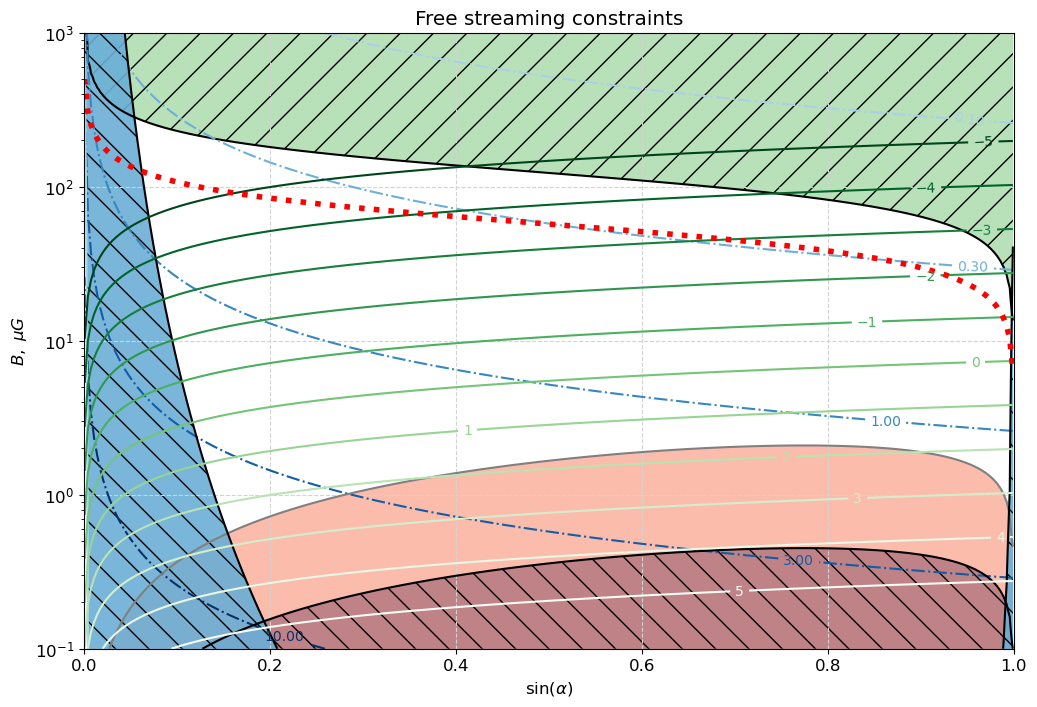

In [62]:
set_plotting_defaults()

fig = plt.figure(figsize=(12, 8))
ax = fig.gca()

# propagation vs. cooling time
ax.contourf(sin_alpha, (mf/uGauss).value, prop_time_grid.value.T - ltime_keV.to(u.yr).value.T,
            levels=[0, 10000], cmap='Greens', alpha=.5, hatches=["/"])
ax.contour(sin_alpha, (mf/uGauss).value, prop_time_grid.value.T - ltime_keV.to(u.yr).value.T,
           levels=[0, 10000], colors=['black', 'black'])

# maximal energy
ctr_e = ax.contour(sin_alpha, (mf/uGauss).value, max_e_grid.value.T,
                   levels=[0.01, 0.03, 0.1, 0.3, 1, 3, 10], norm='log', cmap='Blues', linestyles='dashdot')
ax.clabel(ctr_e, fontsize=10)

# synchrotron power constraint
synch_constraint = mf_grid.to_value(uGauss)**(1.5) * np.sin(alpha_grid)**(-1.5) * np.cos(alpha_grid)**(-1)
ax.contourf(sin_alpha, (mf/uGauss).value, synch_constraint.T, levels=[0, 0.7, 7], hatches=['\\', '', ''], alpha=.5, cmap='Reds_r')
ax.contour(sin_alpha, (mf/uGauss).value, synch_constraint.T, levels=[0.7, 7], norm='log', colors=['black', 'gray'])

# Inverse Compton power constraint
ic_constraint = mf_grid.to_value(uGauss)**(-0.2) * sin_alpha_grid**(-0.2) / sin_2alpha_grid
ax.contourf(sin_alpha, (mf/uGauss).value, ic_constraint.T, levels=[5.33, 533], hatches=['\\'], alpha=.9, cmap='Blues')
ax.contour(sin_alpha, (mf/uGauss).value, ic_constraint.T, levels=[5.33, 533], norm='log', colors=['black', 'lightblue'])

# electron density contours
mf_en_density = mf_grid**2/(8*np.pi)
density_equality = (electron_density / mf_en_density).to_value('')
ct = ax.contour(sin_alpha, (mf/uGauss).value, np.log10(density_equality.T),
                levels=[-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5], cmap='Greens_r',
                linestyles='solid'
                )
ax.clabel(ct, fontsize=10)

# best-fit line
ax.plot(sin_alpha, 50 * (1-sin_alpha**2)**(1/3) * sin_alpha**(-1/3), linewidth=4, color='red', linestyle='dotted')

ax.set_xlabel(r'$\sin(\alpha)$')
ax.set_ylabel(r'$B,~\mu G$')

ax.set_xlim(0, 1)
ax.set_ylim(1e-1, 1e3)

ax.set_title("Free streaming constraints")
ax.set_yscale('log')
plt.show()

In [63]:
a = 30 * u.deg
print(f"Optimal magnetic field: {50 * np.cos(a)**(2/3) * np.sin(a)**(-1/3):.3g} uG")

Optimal magnetic field: 57.2 uG


#### 7. **Simple modeling**

In [64]:
chandra_2023_models, chandra_2023_low, chandra_2023_upper, chandra_2023_areas = get_2023_xray(chandra_2023_range, chandra_2023, if_areawise=False)
nustar_2023_models, nustar_2023_low, nustar_2023_upper, nustar_2023_areas = get_2023_xray(nustar_2023_range, nustar_2023,
                                                                                          if_areawise=False, if_compensation=True)

chandra_2023_range = chandra_2023_range.to(u.eV)
nustar_2023_range = nustar_2023_range.to(u.eV)

In [77]:
B = 5 * uGauss
S = 2.4  # electron index
N0 = 1e42 / u.GeV
Pitch_angle = 30 * u.deg

boundaries = np.array(boundaries)

length = 0.5 * (boundaries[1:] + boundaries[:-1]) * u.arcsec * arcsec_scale
times = (2 * length / (np.sin(2*Pitch_angle) * cst.c)).to(u.yr)

times

<Quantity [28.11841466, 53.68060981, 89.46768301] yr>

In [83]:
Electron_energy = np.logspace(np.log10(synch_electron_energy(0.1*u.keV, B, Pitch_angle).to_value(u.eV)),
                              np.log10(synch_electron_energy(20*u.keV, B, Pitch_angle).to_value(u.eV)),
                              100) * u.eV
Synch_phot_energy = np.logspace(-3, 10, 500) * u.eV  # from 1 meV to 100 keV
IC_phot_energy = np.logspace(3, 15, 300) * u.eV  # from 1 keV to 10 TeV

syn_fs = []
ic_fs = []
energies = []

for i, time in enumerate(times):
    # SYN
    el_sp = cooled_pwl_spectrum(Electron_energy, norm=N0, index=S, t=time, ref=Ref_energy, b=B, alpha=Pitch_angle)
    energies.append(np.trapezoid(el_sp * Electron_energy, Electron_energy).to(u.erg))
        
    syn_lum_exact = electron_synchrotron_emission_luminosity(Electron_energy,
                                                             el_sp,
                                                             Synch_phot_energy,
                                                             B,
                                                             Pitch_angle)
    syn_f_exact = (syn_lum_exact/(2*np.pi*Dist**2) * Synch_phot_energy).to(energy_flux_unit)
    syn_fs.append(syn_f_exact)
    
    # IC
    inv_c = np.zeros([len(Electron_energy), len(IC_phot_energy)]) * 1 / (u.eV**2 * u.s)  # [eV-2 s-1], number of photons in [e, e+de] per electron in [E, E+dE] per second
    for j, ee in enumerate(Electron_energy):
        g = (ee / CST_m_e).to_value('')
        ic_lum_exact = klein_nishina_on_CMB(g, IC_phot_energy)  # [eV-1 s-1], number of photons in [e, e+de] per electron of energy E per second
        inv_c[j] = ic_lum_exact * el_sp[j]
    
    inv_c_lum = np.trapezoid(inv_c, Electron_energy, axis=0) / (2 * np.pi * Dist**2)
    inv_c_f = (inv_c_lum * IC_phot_energy**2).to(energy_flux_unit)
    ic_fs.append(inv_c_f)

In [84]:
print(synch_peak(Electron_energy[0], B, Pitch_angle))

100.00000000000034 eV


In [85]:
total_energy = energies[0]
radius = 10 * u.arcsec * arcsec_scale

volume = np.pi * radius**2 * length[0]
energy_density = total_energy / volume

mf_density = B**2/(8*np.pi)

print(f"Electron energy density: {energy_density.to(u.eV/u.cm**3):.3g}")
print(f"Magnetic field density: {mf_density.to(u.eV/u.cm**3):.3g}")
print(f"Ratio: {(energy_density / mf_density).to_value(''):.2g}")
print(f"Min electron energy: {synch_electron_energy(0.5*u.keV, B, Pitch_angle)}")

Electron energy density: 8.92 eV / cm3
Magnetic field density: 0.621 eV / cm3
Ratio: 14
Min electron energy: 101834940359409.84 eV


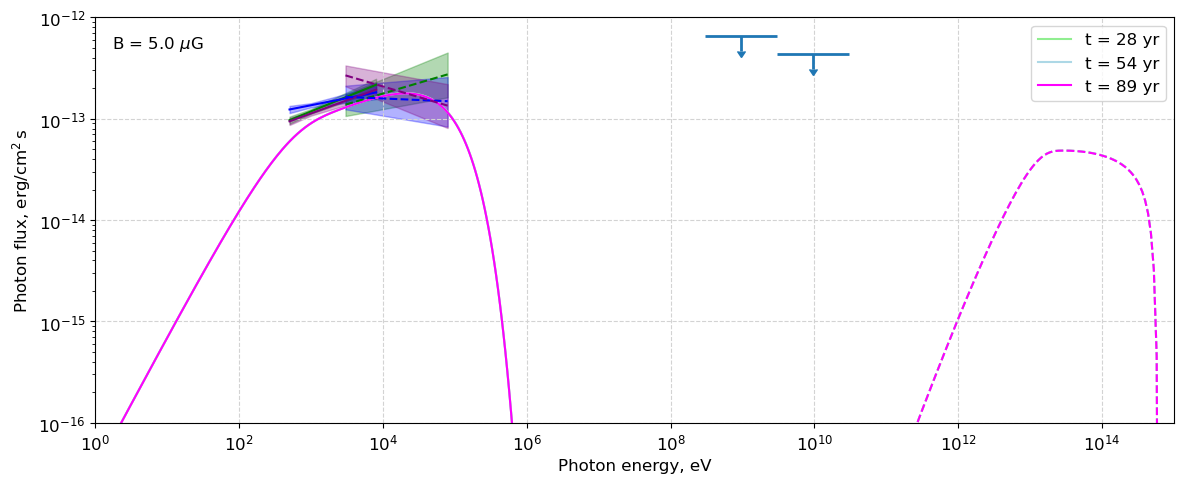

In [86]:
set_plotting_defaults()
plt.figure(figsize=(12, 5))

colors = ['lightgreen', 'lightblue', 'magenta']
for i, time in enumerate(times):
    def el_spectrum(e):
        return cooled_pwl_spectrum(e, norm=N0, index=S, t=time, ref=Ref_energy, b=B, alpha=Pitch_angle)
            
    plt.subplot(111)
    plt.loglog(Synch_phot_energy, syn_fs[i], label=f't = {time:.0f}', color=colors[i])
    
    plt.loglog(IC_phot_energy, ic_fs[i], color=colors[i], linestyle='dashed')
    
plt.subplot(111)
plt.xlabel("Photon energy, eV")
plt.xlim(1e0, 1e15) 
plt.ylabel("Photon flux, "r"$\mathrm{erg/cm^2\,s}$")
plt.ylim(1e-16, 1e-12)
plt.text(1.7e0, 5e-13, f"B = {B / uGauss} "r"$\mu$G")
plt.legend()

colors = ['green', 'blue', 'purple']

# HERE I COMPENSATE FOR THE LENGTHS OF THE REGIONS OF INTEREST!!!
afs = np.array(boundaries[1:]) - np.array(boundaries[:-1])

# chandra data
for i in range(len(chandra_2023_models)):
    af = afs[0] / afs[i]
    plt.loglog(chandra_2023_range, chandra_2023_models[i] * af, color=colors[i])
    plt.fill_between(chandra_2023_range.value, (chandra_2023_low[i] * af).value, (chandra_2023_upper[i] * af).value,
                     alpha=0.3, color=colors[i])

# nustar data
for i in range(len(nustar_2023_models)):
    af = afs[0] / afs[i]
    plt.loglog(nustar_2023_range, nustar_2023_models[i] * af, color=colors[i], linestyle='dashed')
    plt.fill_between(nustar_2023_range.value, (nustar_2023_low[i] * af).value, (nustar_2023_upper[i] * af).value, alpha=0.3, color=colors[i])


# fermi upper limits
plt.errorbar(fermi_energies.to(u.eV), fermi_fluxes, xerr=fermi_errors, yerr=0.3 * fermi_fluxes, uplims=True,
             linewidth=0, elinewidth=2)


plt.tight_layout()
plt.show()

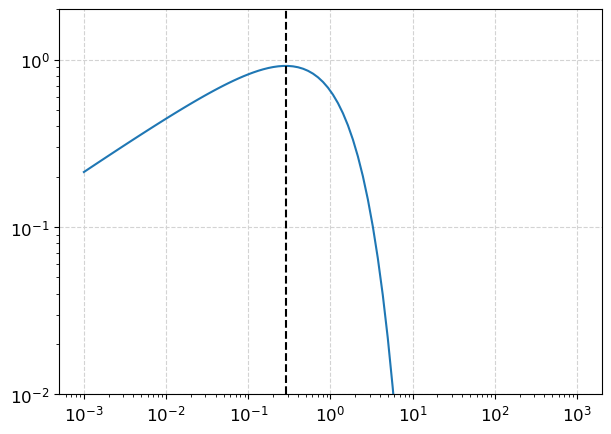

In [87]:
import matplotlib.pyplot as plt
from synchrotron.synchrotron_emission import first_synchrotron_function_approximation
x = np.logspace(-3, 3, 100)
plt.loglog(x, first_synchrotron_function_approximation(x))
plt.ylim(1e-2, 2)
plt.vlines([0.29], 1e-2, 1e2, color='black', linestyle='dashed')
plt.show()